In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics.pairwise import cosine_similarity,euclidean_distances
from sklearn.metrics.pairwise import sigmoid_kernel,linear_kernel,rbf_kernel,polynomial_kernel
from sklearn.feature_extraction.text import TfidfVectorizer

### Data Preprocessing:
Load the dataset into a suitable data structure (e.g., pandas DataFrame).
Handle missing values, if any.
Explore the dataset to understand its structure and attributes.

In [2]:
df=pd.read_csv('anime.csv')

In [3]:
df.shape

(12294, 7)

In [4]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [5]:
df.genre

0                     Drama, Romance, School, Supernatural
1        Action, Adventure, Drama, Fantasy, Magic, Mili...
2        Action, Comedy, Historical, Parody, Samurai, S...
3                                         Sci-Fi, Thriller
4        Action, Comedy, Historical, Parody, Samurai, S...
                               ...                        
12289                                               Hentai
12290                                               Hentai
12291                                               Hentai
12292                                               Hentai
12293                                               Hentai
Name: genre, Length: 12294, dtype: object

In [6]:
## duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
## missing values
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [8]:
df['genre'] = df['genre'].fillna(df['genre'].mode()[0])
df['type'] = df['type'].fillna(df['type'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mean())

In [9]:
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

### Feature Extraction:
Decide on the features that will be used for computing similarity (e.g., genres, user ratings).
Convert categorical features into numerical representations if necessary.
Normalize numerical features if required.

In [10]:
tfidf=TfidfVectorizer(stop_words='english')

In [11]:
import nltk
from nltk.corpus import stopwords
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [12]:
len(stopwords.words('english'))

198

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

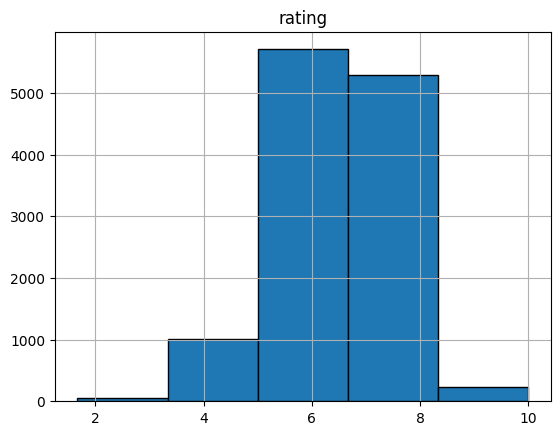

In [13]:
df.hist('rating',bins=5,edgecolor='black')

In [14]:
df['episodes'] = df['episodes'].astype(str).str.strip()
df['episodes'] = df['episodes'].replace('Unknown', None)
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
df['episodes'] = df['episodes'].fillna(df['episodes'].median())

In [15]:
df['members'] = df['members'].astype(str).str.strip()
df['members'] = pd.to_numeric(df['members'], errors='coerce')
df['members'] = df['members'].fillna(df['members'].median())

In [16]:
print(df[['episodes','rating','members']].isnull().sum())
print(df[['episodes','rating','members']].dtypes)

episodes    0
rating      0
members     0
dtype: int64
episodes    float64
rating      float64
members       int64
dtype: object


In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_features = scaler.fit_transform(df[['episodes','rating','members']])

In [18]:
tfidf1=tfidf.fit_transform(df.genre)
tfidf1

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40480 stored elements and shape (12294, 46)>

### Recommendation System:
Design a function to recommend anime based on cosine similarity.
Given a target anime, recommend a list of similar anime based on cosine similarity scores.
Experiment with different threshold values for similarity scores to adjust the recommendation list size.
Analyze the performance of the recommendation system and identify areas of improvement.

### Cosine Similarity

In [19]:
from scipy.sparse import hstack
combined_features = hstack([tfidf1, num_features])

In [20]:
similarity_matrix = cosine_similarity(combined_features)
similarity_matrix.shape

(12294, 12294)

In [42]:
def recommend_anime(anime_name):
    
    # Get index
    idx = df[df['name'] == anime_name].index[0]
    
    # Get similarity scores
    sim_scores = list(enumerate(similarity_matrix[idx]))
    
    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]
    
    # Get indices
    anime_indices = [i[0] for i in sim_scores]
    
    return df['name'].iloc[anime_indices]

In [43]:
recommend_anime("Naruto")

615                                    Naruto: Shippuuden
206                                         Dragon Ball Z
346                                           Dragon Ball
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
1573    Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...
Name: name, dtype: object

In [44]:
def recommend_with_threshold(anime_name, threshold=0.5):
    
    idx = df[df['name'] == anime_name].index[0]
    
    sim_scores = list(enumerate(similarity_matrix[idx]))
    
    filtered = [i for i in sim_scores if i[1] > threshold]
    
    anime_indices = [i[0] for i in filtered if i[0] != idx]
    
    return df['name'].iloc[anime_indices]

In [45]:
print("Threshold = 0.3")
print(recommend_with_threshold("Naruto", 0.3))

print("\nThreshold = 0.5")
print(recommend_with_threshold("Naruto", 0.5))

print("\nThreshold = 0.7")
print(recommend_with_threshold("Naruto", 0.7))

Threshold = 0.3
0                                           Kimi no Na wa.
1                         Fullmetal Alchemist: Brotherhood
2                                                 Gintama°
3                                              Steins;Gate
4                                            Gintama&#039;
                               ...                        
12106                             Sailor Senshi Venus♥Five
12146                                           Dochinpira
12186                                        O-parts: Oman
12221                           Kunoichi Gakuen Ninpouchou
12251    Chou Do M na Hentai Mesu-tachi Otokoton Chouky...
Name: name, Length: 6346, dtype: object

Threshold = 0.5
1          Fullmetal Alchemist: Brotherhood
3                               Steins;Gate
6                    Hunter x Hunter (2011)
12                                  Gintama
13       Code Geass: Hangyaku no Lelouch R2
                        ...                
11834         

### Using Threshold

In [47]:
### improved
combined_features = hstack([tfidf1 *2, num_features])
similarity_matrix = cosine_similarity(combined_features)
similarity_matrix.shape

(12294, 12294)

In [52]:
def recommend_with_threshold(anime_name, threshold=0.5):
    idx = df[df['name'] == anime_name].index[0]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    filtered = [i for i in sim_scores if i[1] > threshold]
    anime_indices = [i[0] for i in filtered if i[0] != idx]
    return df['name'].iloc[anime_indices]

In [53]:
print("Threshold = 0.3")
print(recommend_with_threshold("Naruto", 0.3))

print("\nThreshold = 0.5")
print(recommend_with_threshold("Naruto", 0.5))

print("\nThreshold = 0.7")
print(recommend_with_threshold("Naruto", 0.7))

Threshold = 0.3
1        Fullmetal Alchemist: Brotherhood
2                                Gintama°
4                           Gintama&#039;
6                  Hunter x Hunter (2011)
12                                Gintama
                       ...               
11834                         Mitama: Nin
11930               V.G.Neo The Animation
12020                Sexy Sailor Soldiers
12106            Sailor Senshi Venus♥Five
12221          Kunoichi Gakuen Ninpouchou
Name: name, Length: 1130, dtype: object

Threshold = 0.5
6                                   Hunter x Hunter (2011)
13                      Code Geass: Hangyaku no Lelouch R2
19                         Code Geass: Hangyaku no Lelouch
21       Rurouni Kenshin: Meiji Kenkaku Romantan - Tsui...
23                                           One Punch Man
                               ...                        
11528                                           Kage (OVA)
11565                               Taimanin Asagi S

### Sigmoid kernel

In [54]:
similarities=sigmoid_kernel(tfidf1,tfidf1)
similarities.shape

(12294, 12294)

In [55]:
similarities[1]

array([0.76294071, 0.77057395, 0.76322027, ..., 0.76159416, 0.76159416,
       0.76159416], shape=(12294,))

In [56]:
indices=pd.Series(data=df.index,index=df.name)
indices

name
Kimi no Na wa.                                            0
Fullmetal Alchemist: Brotherhood                          1
Gintama°                                                  2
Steins;Gate                                               3
Gintama&#039;                                             4
                                                      ...  
Toushindai My Lover: Minami tai Mecha-Minami          12289
Under World                                           12290
Violence Gekiga David no Hoshi                        12291
Violence Gekiga Shin David no Hoshi: Inma Densetsu    12292
Yasuji no Pornorama: Yacchimae!!                      12293
Length: 12294, dtype: int64

In [57]:
def recommend_anime(anime_name):
    
    # Get index
    idx = df[df['name'] == anime_name].index[0]
    # Get similarity scores
    sim_scores = list(enumerate(similarities[idx]))
    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]
    # Get indices
    anime_indices = [i[0] for i in sim_scores]
    return df['name'].iloc[anime_indices]

In [58]:
recommend_anime("Naruto")

615                                    Naruto: Shippuuden
841                                                Naruto
1103    Boruto: Naruto the Movie - Naruto ga Hokage ni...
1343                                          Naruto x UT
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
Name: name, dtype: object

### Interview Questions:
1. Can you explain the difference between user-based and item-based collaborative filtering?
2. What is collaborative filtering, and how does it work?